# yfinance Library Assignment  

In [34]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

### Function Specification: `download_historical_data`

Implement the function `download_historical_data` to fetch historical price data using Yahoo Finance as the data source. This function should be capable of fetching historical data for a specified stock symbol between given start and end dates. Additionally, it should support an optional parameter for the data timeframe with a default value of `'1d'` (daily).

---

### Function Specifications

**Parameters:**
- `symbol`: The ticker symbol of the stock (e.g., `'RELIANCE.NS'`).
- `start_date`: Start date for the data in `'YYYY-MM-DD'` format.
- `end_date`: End date for the data in `'YYYY-MM-DD'` format.
- `timeframe`: The frequency of the data (`'1d'`, `'1wk'`, `'1mo'`), default is `'1d'`.

**Return:**  
A pandas `DataFrame` containing the fetched data.


In [39]:
# Code Here 
def download_historical_data (symbol, start_date, end_date,timeframe = '1d'):
    ticker = yf.Ticker(symbol)
    data = ticker.history(interval = timeframe, start = start_date, end = end_date)
    return data

### Visualization

Create a function for plotting the stock closing prices. This function should accept parameters for the plot and its objective is to display the graph.
   


In [49]:
# Code here 
def closing_prices(dataframe,title = "Closing price graph"):
    x_axis = dataframe.index
    y_axis = dataframe['Close']

    plt.figure(figsize = (16,9))
    plt.title(title)
    plt.grid(True)
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.plot(x_axis,y_axis)
    plt.show()


### Run the functions 

**Choose Stocks:**  
   - Select any three stocks of your choice.
   - Fetch their data for the time period from **2012 to 2022**.
   - Select daily time frame i.e. 1d.

**Plot the Data:**  
   1. Plot the data for each stock separately.  
   2. Combine the data and plot all three stocks on the **same graph** for comparison.

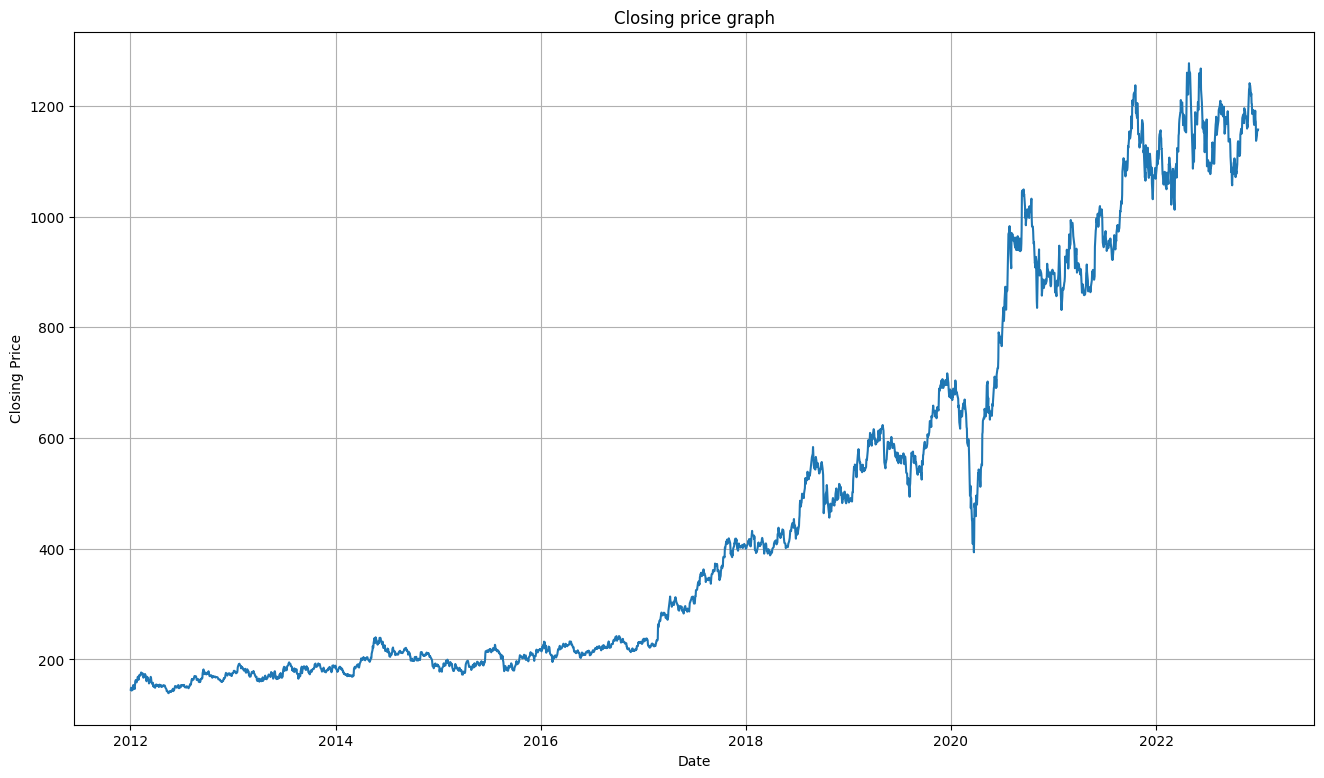

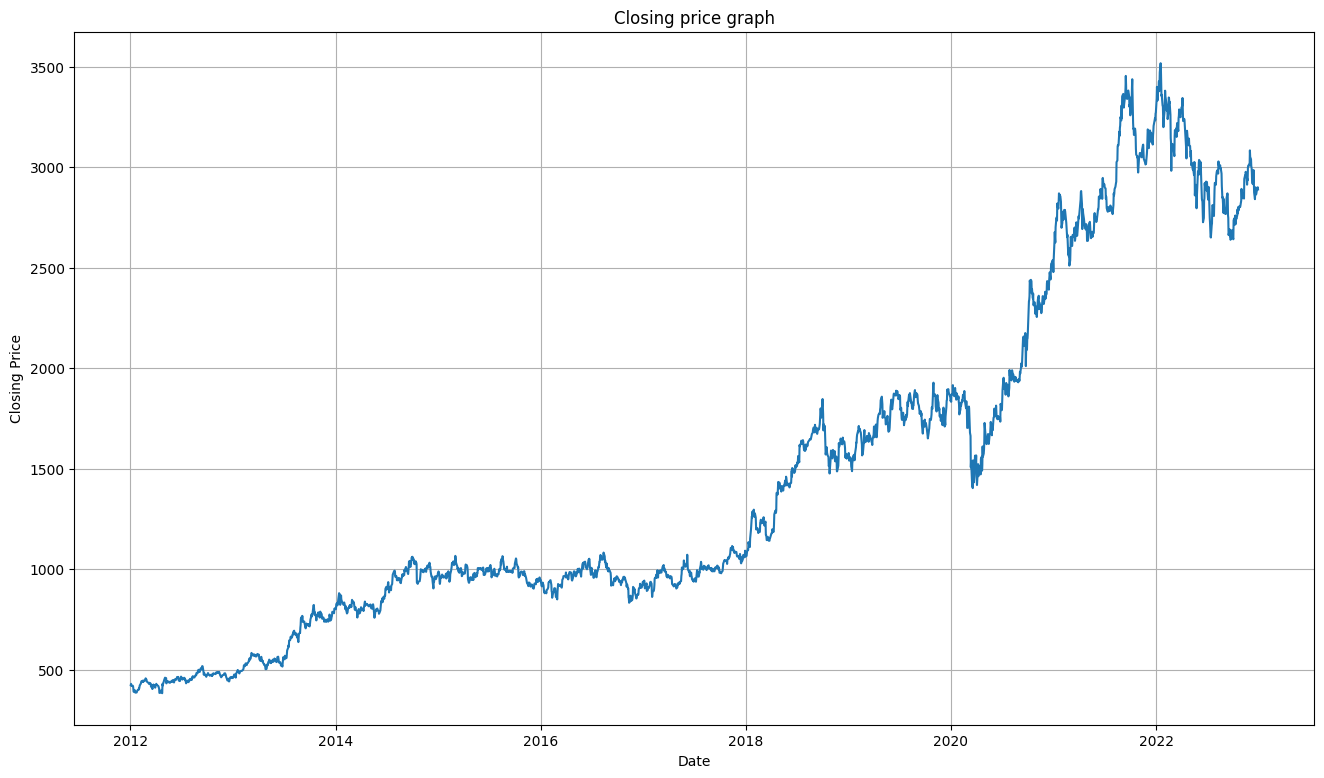

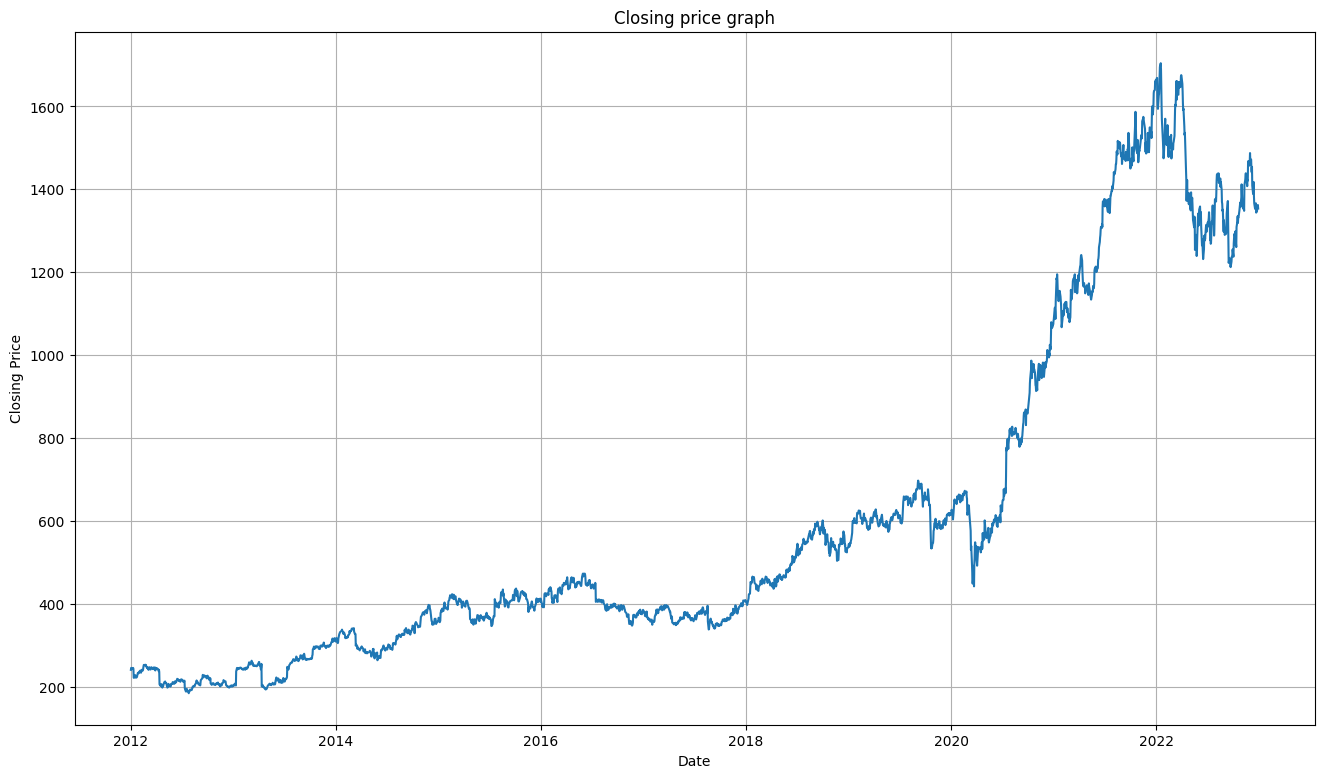

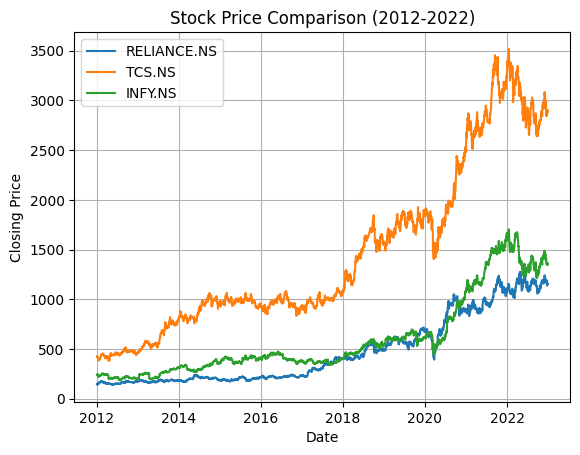

In [53]:
# Code here 
stocks = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS']

dataframe = {}

for stock in stocks:
    dataframe[stock] = download_historical_data(
        symbol=stock,
        start_date='2012-01-01',
        end_date='2022-12-31',
        timeframe='1d'
    )

for stock in dataframe:
    closing_prices(dataframe[stock])

for stock, data in dataframe.items():
    plt.plot(data.index, data['Close'], label = stock)

plt.title('Stock Price Comparison (2012-2022)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.show()


### Technical Analysis 

**Simple Moving Averages (SMA) and Exponential Moving Averages (EMA)**  
   - Plot the SMA and EMA of 5 days of each of the three stocks that you have selected.
   - SMA and EMA graph should be plotted on the same graph 
   - Hence you have to plot three graphs of each stock with SMA and EMA
    

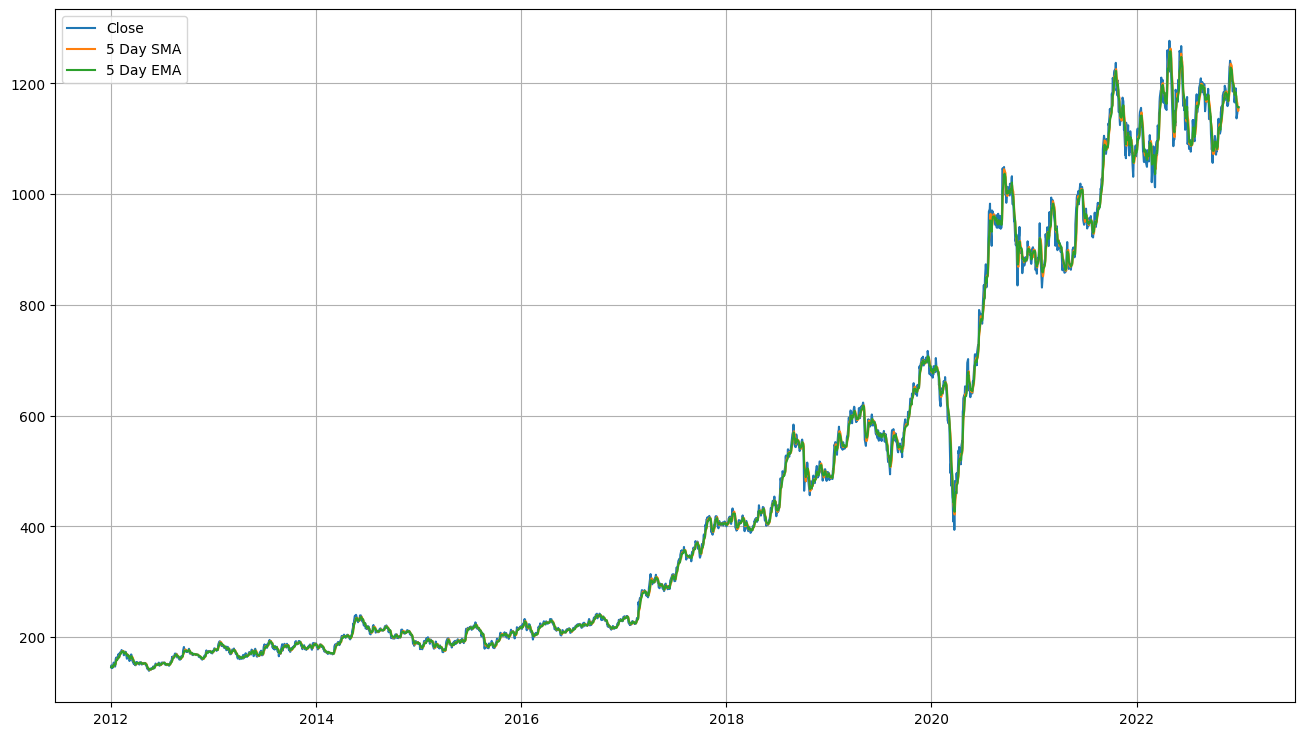

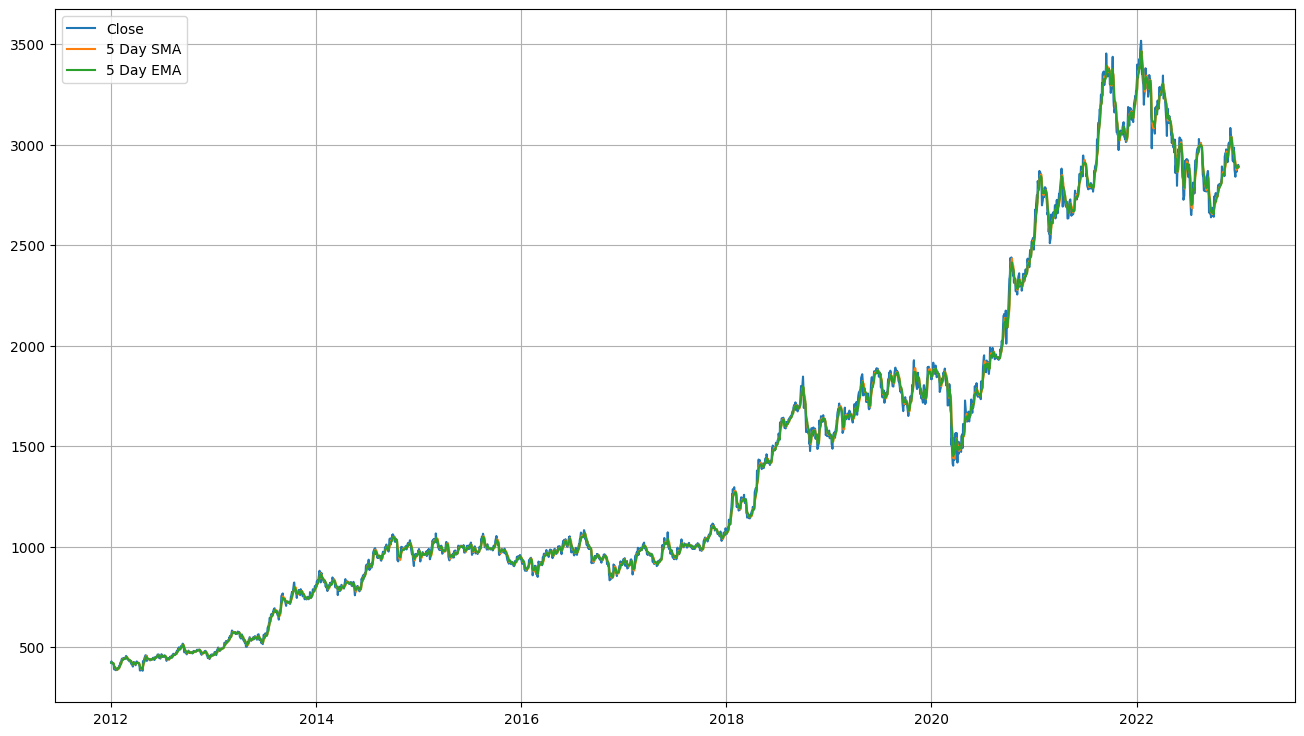

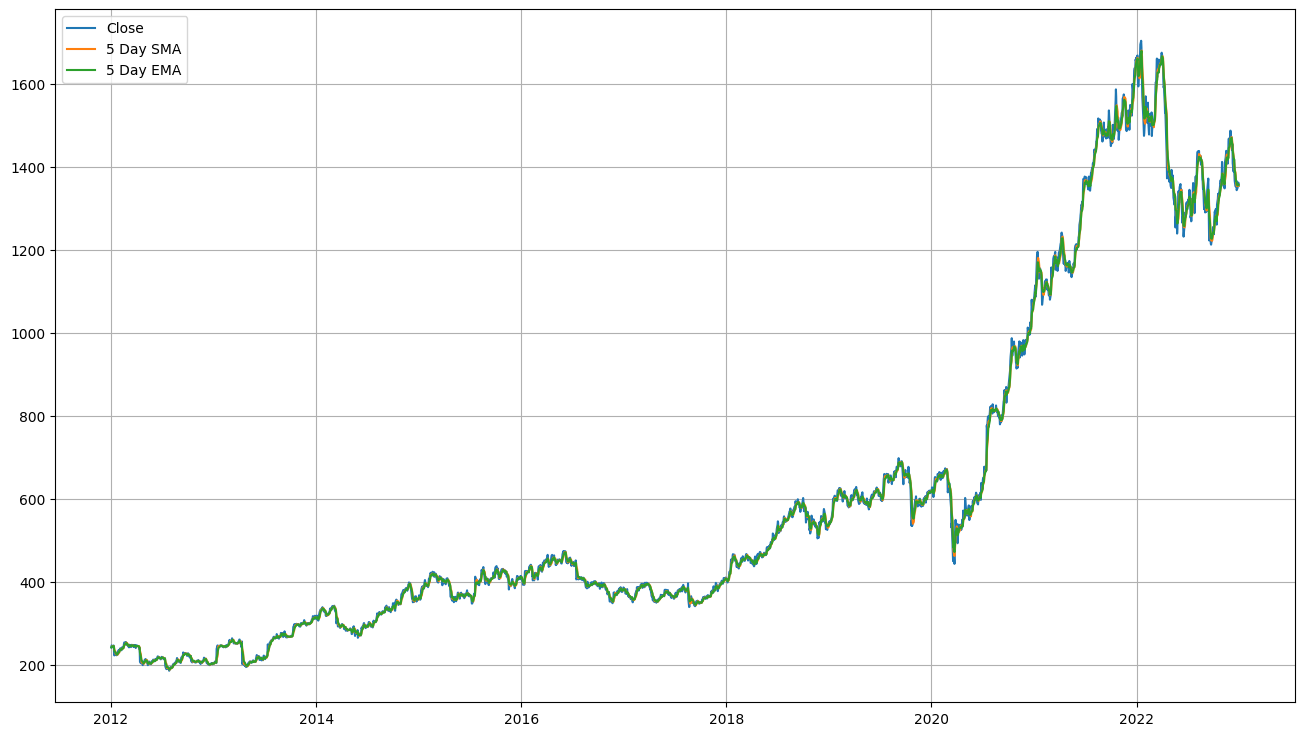

In [61]:
# Code here 

for data in dataframe.values():
    data["SMA_5"] = data["Close"].rolling(window=5).mean()
    data["EMA_5"] = data["Close"].ewm(span=5, adjust=False).mean()

    plt.figure(figsize=(16,9))
    
    plt.plot(data.index, data["Close"], label="Close")
    plt.plot(data.index, data["SMA_5"], label="5 Day SMA")
    plt.plot(data.index, data["EMA_5"], label="5 Day EMA")
    
    plt.legend()
    plt.grid(True)
    plt.show()

**MACD**  
   - Plot MACD and Signal line for each of the three stocks.
   - Fast Length (Short-term EMA): 12 periods
   - Slow Length (Long-term EMA): 26 periods
   - Signal Line (Smoothing EMA): 9 periods

    

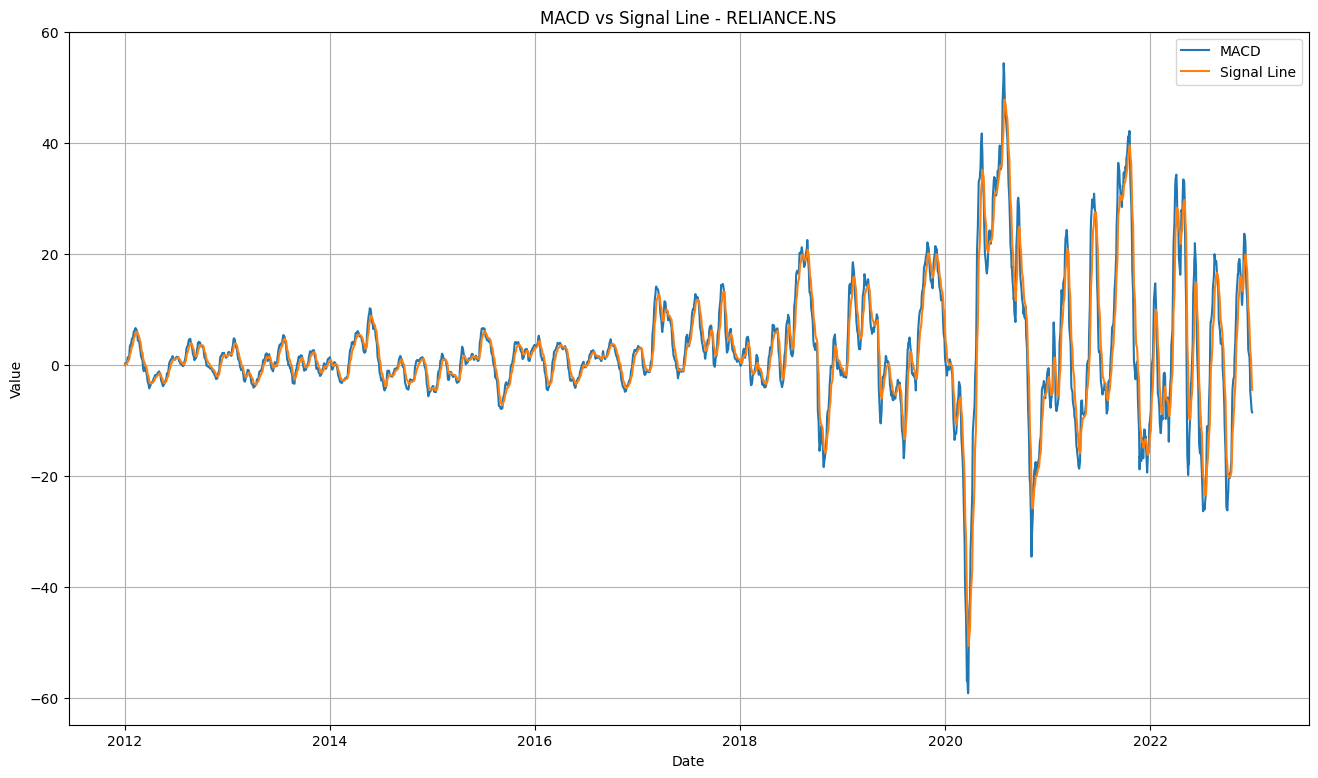

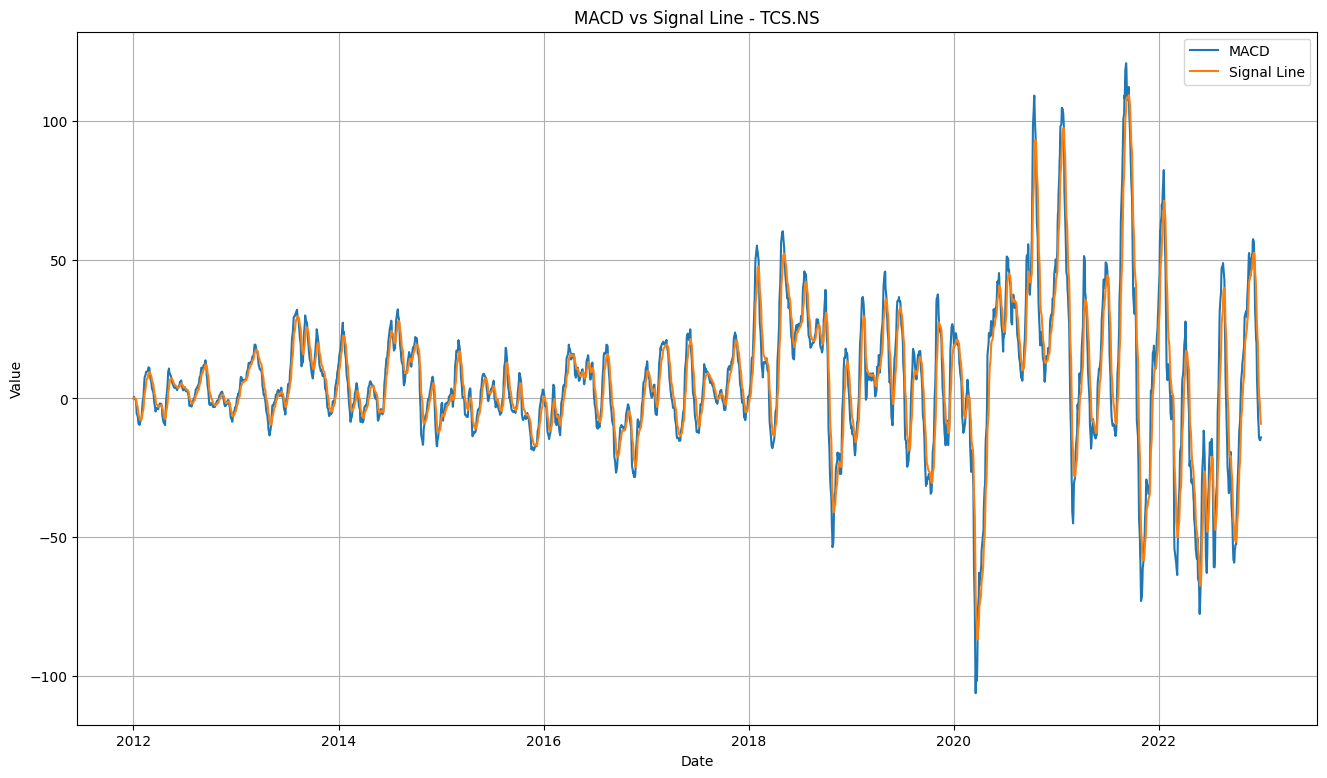

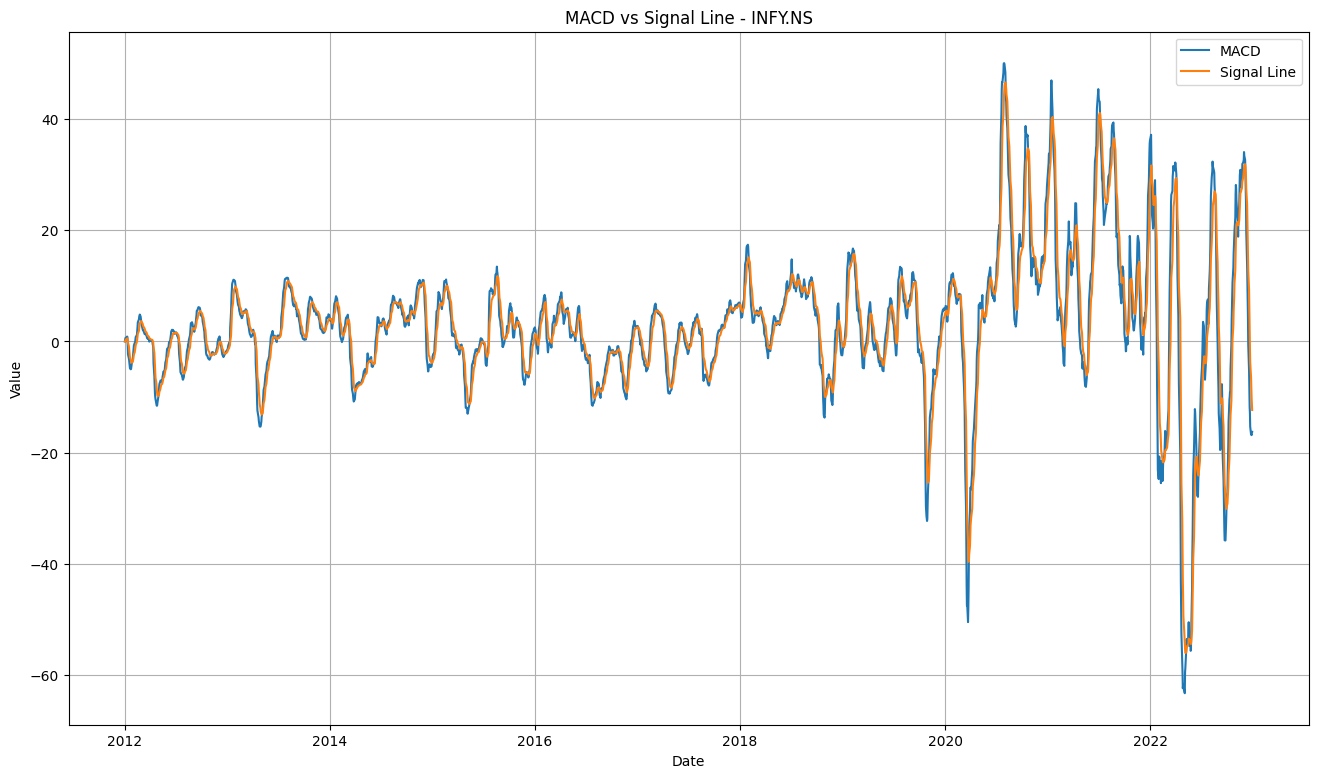

In [62]:
# Code Here
import matplotlib.pyplot as plt

for stock, data in dataframe.items():

    # Calculate MACD
    data['EMA12'] = data['Close'].ewm(span=12, adjust=False).mean()
    data['EMA26'] = data['Close'].ewm(span=26, adjust=False).mean()

    data['MACD'] = data['EMA12'] - data['EMA26']
    data['Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

    # Plot
    plt.figure(figsize=(16, 9))

    plt.plot(data.index, data['MACD'], label='MACD')
    plt.plot(data.index, data['Signal'], label='Signal Line')

    plt.title(f'MACD vs Signal Line - {stock}')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)

    plt.show()

**RSI**  
   - Plot RSI for each of the three stocks
   - Period = 14 days 
   - Also show the overbought and oversold regions 
   - Overbought condition: RSI above 70
   - Oversold condition: RSI below 30
   
    

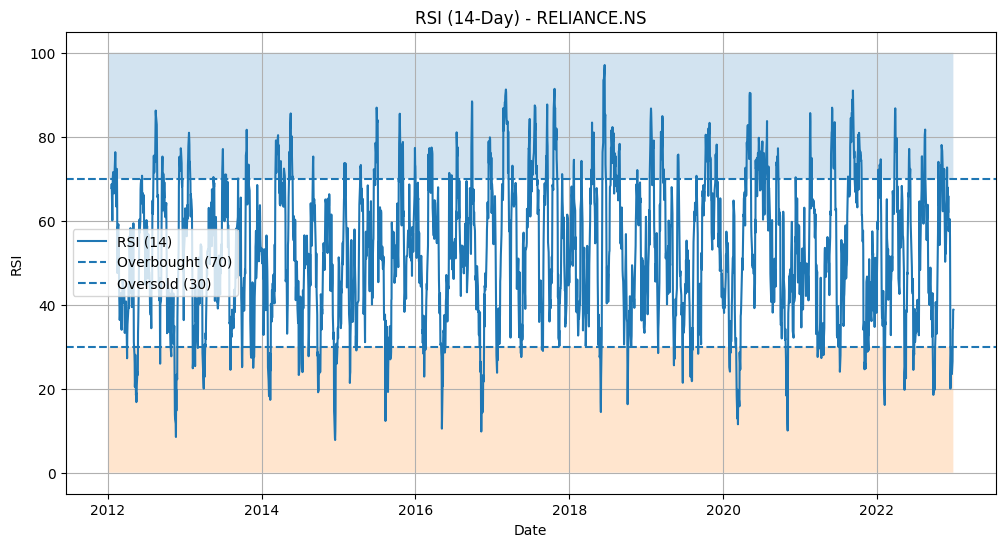

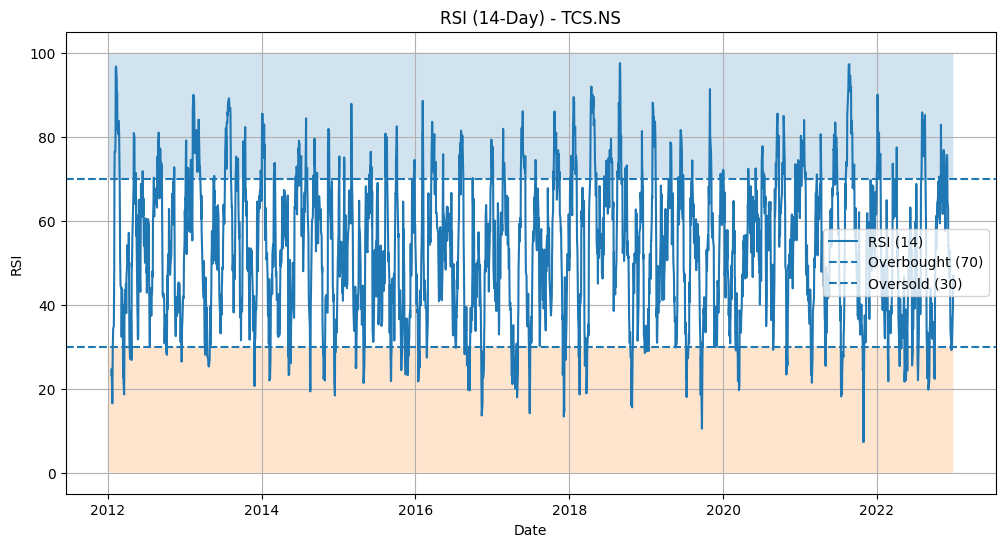

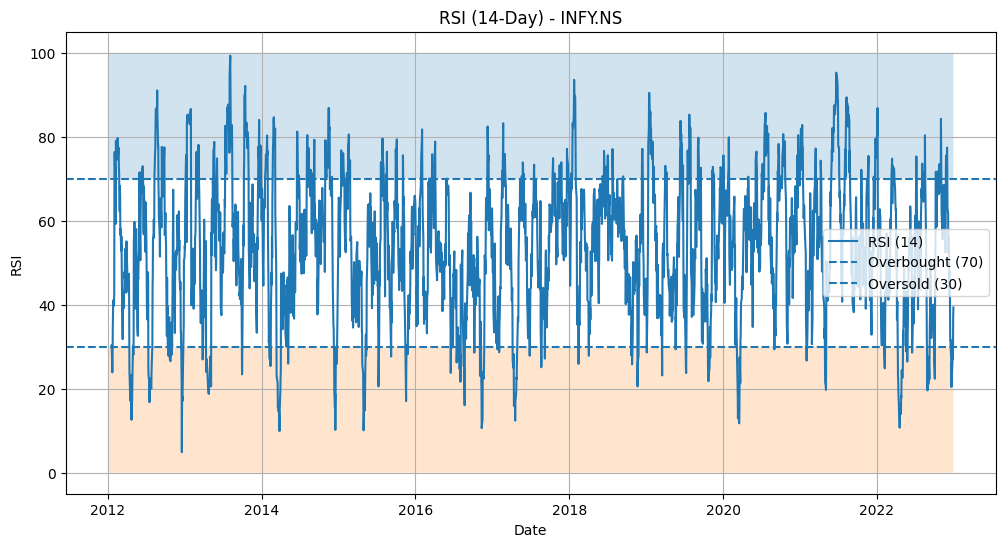

In [63]:
# Code here
for stock, data in dataframe.items():
    # parameters for calculating rsi
    delta = data['Close'].diff()

    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()

    rs = avg_gain / avg_loss

    data['RSI'] = 100 - (100 / (1 + rs))

    plt.figure(figsize=(12, 6))

    plt.plot(data.index, data['RSI'], label='RSI (14)')

    
    plt.axhline(y=70, linestyle='--', label='Overbought (70)')
    plt.axhline(y=30, linestyle='--', label='Oversold (30)')

    plt.fill_between(data.index, 70, 100, alpha=0.2)
    plt.fill_between(data.index, 0, 30, alpha=0.2)

    plt.title(f'RSI (14-Day) - {stock}')
    plt.xlabel('Date')
    plt.ylabel('RSI')
    plt.legend()
    plt.grid(True)

    plt.show()

### Summarize your analysis

In [ ]:
""" Write your answer here 

Historical daily stock data for RELIANCE.NS, TCS.NS, and INFY.NS from 2012 to 2022 was downloaded and analyzed. 
The closing price trends showed an overall upward movement over the long term, reflecting growth in the companies' market value despite periodic market fluctuations.
Technical indicators SMA, EMA, MACD, RSI were calculated to evaluate market trends and momentum. 
The SMA and EMA helped identify the overall trend direction, while MACD highlighted bullish and bearish momentum shifts through crossovers between the MACD and Signal lines.
The RSI analysis identified periods of overbought (RSI > 70) and oversold (RSI < 30) conditions, providing insights into potential reversal points. 
Overall, the combination of price trends and technical indicators demonstrated how quantitative methods can be used to analyze stock performance and support investment decision-making."""